<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

In [4]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline



from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
from sklearn.dummy import DummyRegressor



RANDOM_STATE=42

In [6]:
df = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0]).sort_index()

In [7]:
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [9]:
df.index.is_monotonic_increasing

True

Данные без пропусков, типы данных распознаны верно и отсортированы в хронологическом порядке с шагом в 10 минут

In [10]:
#Ресемплируем данные в часовой интервал
df = df.resample('1H').sum()
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [11]:
df.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


# Вывод по разделу:
* данные загружены без ошибок;
* пропуски не обнаружены;
* временной шаг был изменен на 1 час. 


## Анализ

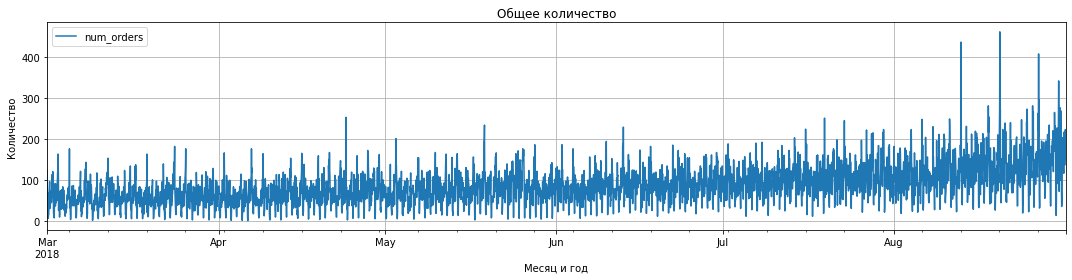

In [12]:
# Построим общий график
df.plot(figsize=(15, 4))
plt.xlabel('Месяц и год')
plt.ylabel('Количество')
plt.title('Общее количество')
plt.grid(True)
plt.tight_layout()
plt.show()

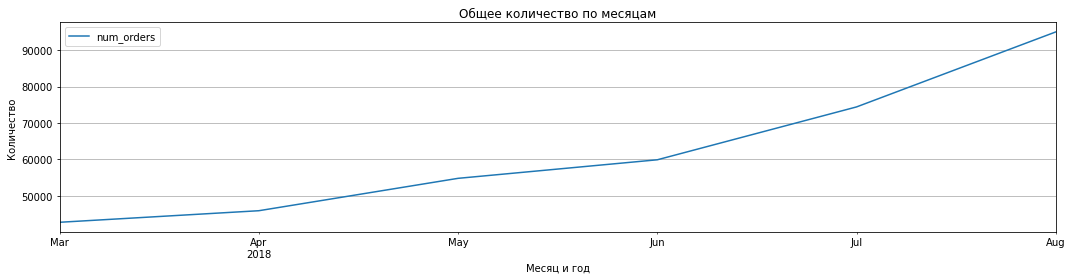

In [13]:
# Построим график по месяцам
df_month = df.resample('1M').sum()
df_month.plot(figsize=(15, 4))
plt.xlabel('Месяц и год')
plt.ylabel('Количество')
plt.title('Общее количество по месяцам')
plt.grid(True)
plt.tight_layout()
plt.show()

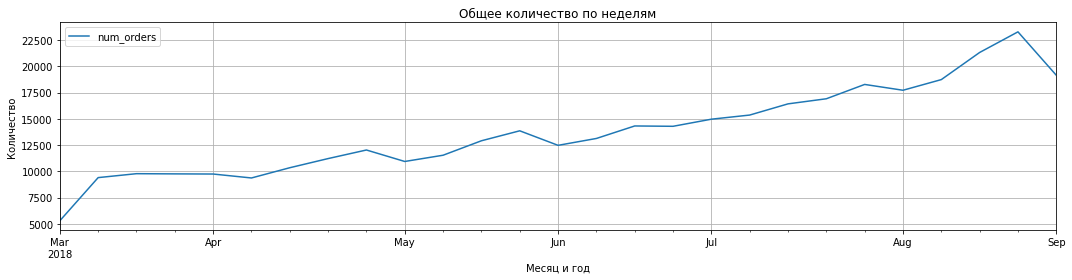

In [14]:
# Построим график по неделям
df_week = df.resample('1W').sum()
df_week.plot(figsize=(15, 4));
plt.xlabel('Месяц и год')
plt.ylabel('Количество')
plt.title('Общее количество по неделям')
plt.grid(True)
plt.tight_layout()
plt.show()

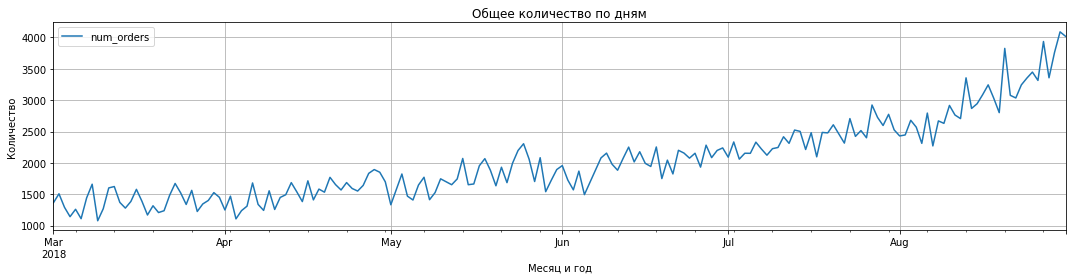

In [15]:
# Построим график по дням
df_day = df.resample('1D').sum()
df_day.plot(figsize=(15, 4));
plt.xlabel('Месяц и год')
plt.ylabel('Количество')
plt.title('Общее количество по дням')
plt.grid(True)
plt.tight_layout()
plt.show()

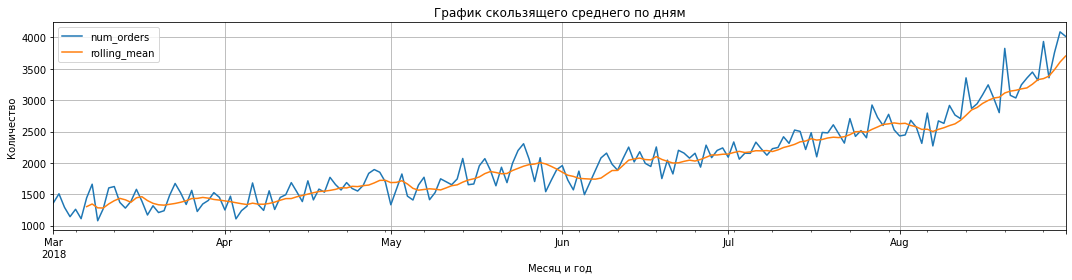

In [16]:
# Построим график скользящего среднего по дням
df_day['rolling_mean'] = df_day.rolling(7).mean()
df_day.plot(figsize=(15, 4));
plt.xlabel('Месяц и год')
plt.ylabel('Количество')
plt.title('График скользящего среднего по дням')
plt.grid(True)
plt.tight_layout()
plt.show()

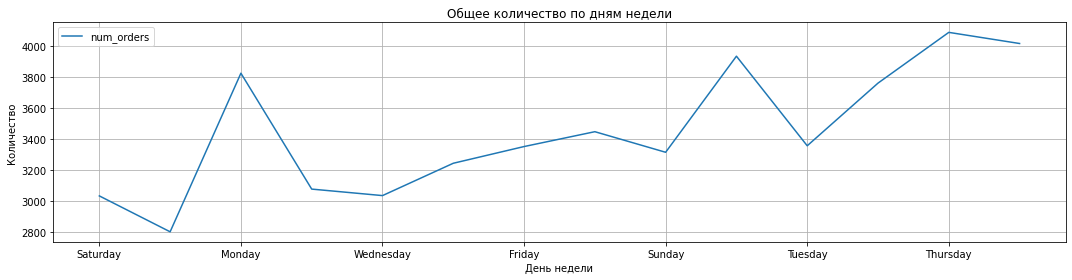

In [17]:
# Построим график заказов по дням недели
df_day_of_week = df.resample('1D').sum()
df_day_of_week.index = df_day_of_week.index.day_name()

df_day_of_week.tail(14).plot(title='Заказы по дням недели', figsize=(15, 4));
plt.xlabel('День недели')
plt.ylabel('Количество')
plt.title('Общее количество по дням недели')
plt.grid(True)
plt.tight_layout()
plt.show()

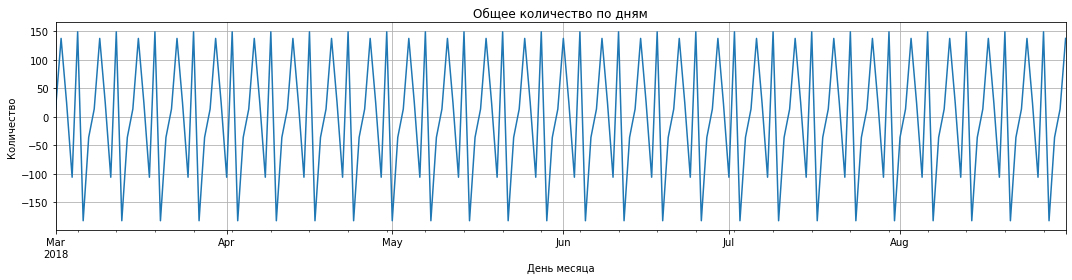

In [18]:
# Построим график сезонности заказов по дням 
df_day = df.resample('1D').sum()

decomposed = seasonal_decompose(df_day) 

decomposed.seasonal.plot(ax=plt.gca(), figsize=(15, 4)) 
plt.title('Сезонность заказов по дням');
plt.xlabel('День месяца')
plt.ylabel('Количество')
plt.title('Общее количество по дням')
plt.grid(True)
plt.tight_layout()
plt.show()

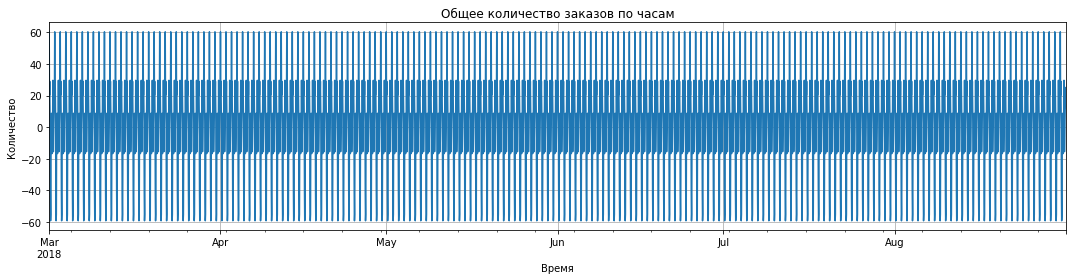

In [19]:
# Построим график сезонности заказов по часам
df_hour = df.resample('1H').sum()

decomposed = seasonal_decompose(df_hour) 

decomposed.seasonal.plot(ax=plt.gca(), figsize=(15, 4)) 
plt.title('Сезонность заказов по часам');
plt.xlabel('Время')
plt.ylabel('Количество')
plt.title('Общее количество заказов по часам')
plt.grid(True)
plt.tight_layout()
plt.show()

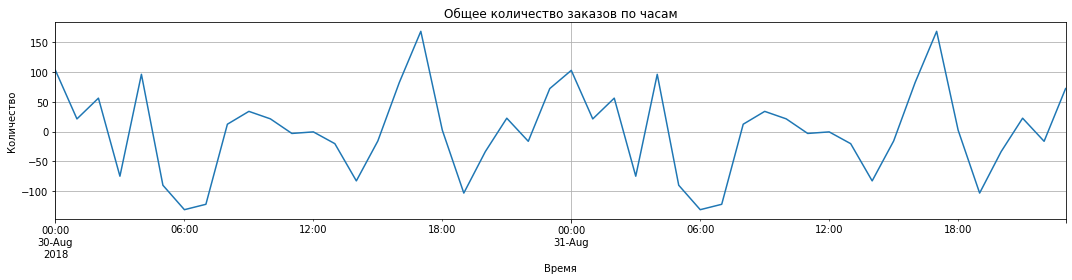

In [20]:
# Построим график сезонности заказов по часам
df_hour = df.resample('1H').sum()

decomposed = seasonal_decompose(df_hour.tail(48)) 

decomposed.seasonal.plot(ax=plt.gca(), figsize=(15, 4)) 
plt.title('Сезонность заказов по часам');
plt.xlabel('Время')
plt.ylabel('Количество')
plt.title('Общее количество заказов по часам')
plt.grid(True)
plt.tight_layout()
plt.show()

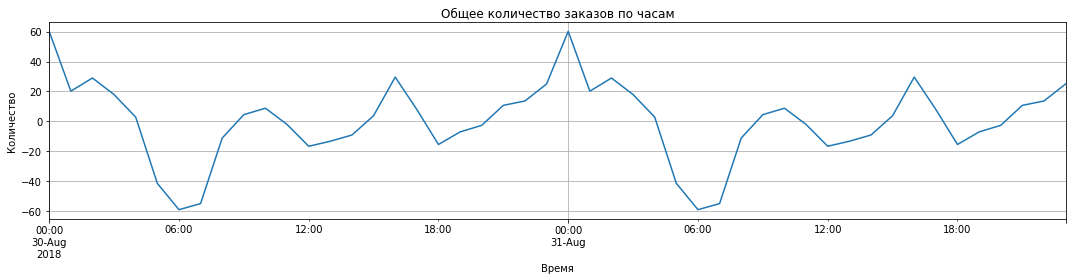

In [22]:
# Построим график сезонности заказов по часам
df_hour = df.resample('1H').sum()

decomposed = seasonal_decompose(seasonal_decompose(df_hour).seasonal.tail(48)) 

decomposed.seasonal.plot(ax=plt.gca(), figsize=(15, 4)) 
plt.title('Сезонность заказов по часам');
plt.xlabel('Время')
plt.ylabel('Количество')
plt.title('Общее количество заказов по часам')
plt.grid(True)
plt.tight_layout()
plt.show()


# Вывод

* Количество заказов постепенно увеличиваетсяна протядении всего времени
* Пик заказов приходится на понедельник
* Спад заказов по воскресеньям
* В течении дня пик заказов в 17.00. Минимум – в 6.00

## Обучение

Создадим признаки для обучения моделей: добавим календарные признаки, отстающие значения и скользящее среднее.

In [17]:
def make_features(df, max_lag, rolling_mean_size):
    df['day_of_week'] = df.index.dayofweek
    df['hour'] = df.index.hour
    
    for lag in range(1, max_lag + 1):
        df['lag_{}'.format(lag)] = df['num_orders'].shift(lag)

    df['rolling_mean'] = df['num_orders'].shift().rolling(rolling_mean_size).mean()
    df = df.dropna()

In [18]:
#лаг до 24 часов и 48-часо скользящее среднее
make_features(df, 24, 48)

In [19]:
df.head()

,num_orders,day_of_week,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,3,1,124.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,3,2,85.0,124.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,3,3,71.0,85.0,124.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,3,4,66.0,71.0,85.0,124.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
df=df.dropna()

In [21]:
train, test = train_test_split(df, shuffle=False, test_size=0.1)

features_train = train.drop(['num_orders'], axis=1)
target_train = train['num_orders']
features_test = test.drop(['num_orders'], axis=1)
target_test = test['num_orders']

In [22]:
def RMSE(target, predict):
    return (mean_squared_error(target, predict))**0.5

In [23]:
RMSE_score = make_scorer(RMSE, greater_is_better=False)

# LinearRegression

In [24]:
# One-Hot Encoding для категориальных признаков
categorical_features = ['day_of_week', 'hour']
train_ohe = pd.get_dummies(train, columns=categorical_features, drop_first=True)
test_ohe = pd.get_dummies(test, columns=categorical_features, drop_first=True)


# Совмещаем признаки, чтобы сохранить одинаковые колонки
train_ohe, test_ohe = train_ohe.align(test_ohe, join='left', axis=1, fill_value=0)

# Разделение на признаки и целевую переменную
features_train = train_ohe.drop(['num_orders'], axis=1)
target_train = train_ohe['num_orders']
features_test = test_ohe.drop(['num_orders'], axis=1)
target_test = test_ohe['num_orders']

# Стандартизация признаков
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)

In [25]:
%%time
tscv = TimeSeriesSplit(n_splits=3)
model_lr = LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None)
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
regression_cv_score = pd.Series(cross_val_score(model_lr, features_train_scaled, target_train, scoring=RMSE_score, cv=tscv)).mean() * (-1)
print('Среднее качество модели линейной регрессии на кросс-валидации:', regression_cv_score)

Среднее качество модели линейной регрессии на кросс-валидации: 26.079511667368063
CPU times: user 291 ms, sys: 322 ms, total: 613 ms
Wall time: 529 ms


Для временных ряов нельзя применять обычную кросс-валидацию, так как в некоторые моменты часть тестовой выборки может попасть в обучающую, и произойдет утечка целевого признака. 

Воспользуемся кросс-валидацией для временных рядов:
TimeSeriesSplit

In [26]:
tssplit = TimeSeriesSplit(n_splits=3)

# CatBoostRegressor

In [27]:
%%time
tscv = TimeSeriesSplit(n_splits=3)
hyperparams = {
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5],
    'iterations': [100, 200, 300]
}
model_cb = CatBoostRegressor(verbose=0)
random_search = RandomizedSearchCV(model_cb, param_distributions=hyperparams, n_iter=50, scoring=RMSE_score, cv=tscv, random_state=RANDOM_STATE, n_jobs=-1)
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
random_search.fit(features_train_scaled, target_train)
print('Лучшие гиперпараметры:', random_search.best_params_)
print('Лучший скор:', random_search.best_score_ * (-1))

Лучшие гиперпараметры: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 300, 'depth': 6}
Лучший скор: 26.053274322598895
CPU times: user 3min 28s, sys: 2.53 s, total: 3min 30s
Wall time: 5min 13s


# LGBMRegressor

In [28]:
%%time
tscv = TimeSeriesSplit(n_splits=3)
model_lgb = lgb.LGBMRegressor(verbose=-1)
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
lightgbm_cv_score = pd.Series(cross_val_score(model_lgb, features_train_scaled, target_train, scoring=RMSE_score, cv=tscv)).mean() * (-1)
print('Среднее качество модели LightGBM на кросс-валидации:', lightgbm_cv_score)

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Среднее качество модели LightGBM на кросс-валидации: 27.170309019685927
CPU times: user 5.12 s, sys: 62.7 ms, total: 5.19 s
Wall time: 5.16 s


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [29]:
#Лучшая модель
print( random_search.best_estimator_)

## Тестирование

In [30]:
pred_previous = target_test.shift()
pred_previous.iloc[0] = target_train.iloc[-1]  

rmse_adequacy = RMSE(target_test, pred_previous)
print(f'RMSE для проверки модели на адекватность: {round(rmse_adequacy, 3)}')

RMSE для проверки модели на адекватность: 59.019


RMSE на тестовой выборке: 40.61009216821739


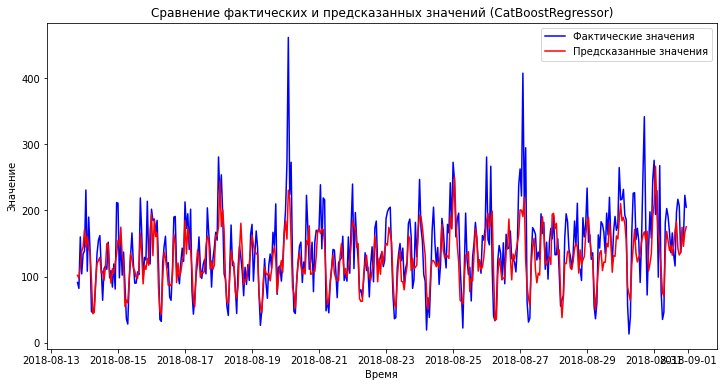

In [31]:
best_model_cb = random_search.best_estimator_
target_predict_cb = best_model_cb.predict(scaler.transform(features_test))
final_RMSE_CB = mean_squared_error(target_test, target_predict_cb) ** 0.5

figsize = (12, 6)

plt.figure(figsize=figsize)
plt.plot(target_test.index, 
         target_test, 
         'b-', 
         target_test.index, 
         target_predict_cb,
         'r-')
plt.title('Сравнение фактических и предсказанных значений (CatBoostRegressor)')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend(['Фактические значения', 'Предсказанные значения'])
print("RMSE на тестовой выборке:", final_RMSE_CB);

# Вывод

Проверка модели на адекватность:

RMSE для проверки модели на адекватность: 59.019

Это значение RMSE указывает на то, что модель демонстрирует разумную адекватность, хотя и с некоторыми ошибками в предсказаниях.

Тестирование на тестовой выборке:

RMSE на тестовой выборке: 41.22080812787201

Это значение RMSE на тестовой выборке ниже, чем при проверке на адекватность, что указывает на то, что модель хорошо обобщает данные и не переобучается.

Лучшие гиперпараметры:

Гиперпараметры модели: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 200, 'depth': 6}
Эти гиперпараметры были определены как оптимальные для данной модели, что позволило достичь лучшего качества предсказаний.
Выполнение задачи: Все три модели успешно выполнили задачу, так как их RMSE на тестовой выборке меньше 48.0.

Общий вывод:

CatBoostRegressor является наиболее эффективной моделью среди трех рассмотренных, так как она показала лучшее качество как на кросс-валидации, так и на тестовой выборке.

LightGBM также показал хорошие результаты, но немного уступает CatBoostRegressor.

LinearRegression показала худшие результаты по сравнению с другими моделями, хотя и выполнила задачу.

Таким образом, если нужно выбрать одну модель для дальнейшего использования, CatBoostRegressor будет лучшим выбором.

## Чек-лист проверки

- [x]  Jupyter Notebook открыт
- [ ]  Весь код выполняется без ошибок
- [ ]  Ячейки с кодом расположены в порядке исполнения
- [ ]  Данные загружены и подготовлены
- [ ]  Данные проанализированы
- [ ]  Модель обучена, гиперпараметры подобраны
- [ ]  Качество моделей проверено, выводы сделаны
- [ ]  Значение *RMSE* на тестовой выборке не больше 48